<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/XGBoost_Preprocessing_ModelTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# IMPORTS
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve, average_precision_score, make_scorer
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
file_path = '/content/drive/MyDrive/Customer_Churn_Data.csv'
df = pd.read_csv(file_path)
df_copy = df.copy()

## Data Preprocessing

In [4]:
# convert TotalCharges to numeric
df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# impute missing values
mask_missing = df['TotalCharges_numeric'].isna()
mask_non_missing = df['TotalCharges_numeric'].notna()
df['calc_total'] = df['MonthlyCharges'] * df['tenure']
df['diff'] = df['TotalCharges_numeric'] - df['calc_total']
mean_diff = df.loc[mask_non_missing, 'diff'].mean()
df.loc[mask_missing, 'TotalCharges_numeric'] = df.loc[mask_missing, 'MonthlyCharges'] * df.loc[mask_missing, 'tenure'] + mean_diff

# drop helpers and original TotalCharges
df.drop(columns=['TotalCharges','calc_total','diff'], inplace=True)

# drop customerID
df.drop(columns=['customerID'], inplace=True)

# encode categorical features
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str)).astype(int)

# encode target
df['Churn'] = df['Churn'].str.strip().map({'No':0,'Yes':1})

# split dataset and apply SMOTE
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("X_train shape after SMOTE:", X_train_res.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution after SMOTE:\n", y_train_res.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape after SMOTE: (8278, 19)
X_test shape: (1409, 19)
y_train distribution after SMOTE:
 Churn
0    0.5
1    0.5
Name: proportion, dtype: float64
y_test distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [5]:
def xgb_random_search(X_train, y_train, n_iter=25):
    param_dist = {
        'n_estimators': [100,150],
        'max_depth': [3,5,7],
        'learning_rate': [0.05,0.1],
        'subsample': [0.8,1],
        'colsample_bytree': [0.8,1],
        'gamma':[0,0.1],
        'min_child_weight':[1,3]
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scorer = make_scorer(f1_score)
    xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    random_search = RandomizedSearchCV(
        estimator=xgb_clf,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=f1_scorer,
        cv=skf,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    random_search.fit(X_train, y_train)
    print("best parameters:", random_search.best_params_)
    print("best f1 score:", random_search.best_score_)
    return random_search.best_estimator_, random_search

In [14]:
def train_xgb(X_train_res, y_train_res, X_test, y_test, model_params=None,
              threshold_start=0.1, threshold_stop=0.7, threshold_step=0.01, random_state=42):

    if model_params is None:
        model_params = {}

    # remove keys that will conflict
    model_params.pop('use_label_encoder', None)
    model_params.pop('eval_metric', None)

    model_params['random_state'] = random_state

    # create model
    model = xgb.XGBClassifier(**model_params, use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train_res, y_train_res)

    # threshold tuning
    test_prob = model.predict_proba(X_test)[:,1]
    best_f1 = 0
    best_threshold = 0.5
    for t in np.arange(threshold_start, threshold_stop, threshold_step):
        test_pred = (test_prob >= t).astype(int)
        f1 = f1_score(y_test, test_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t
    print("best threshold:", best_threshold)
    return model, best_threshold

In [12]:
def evaluate_xgb_model(model, X_train, y_train, X_test, y_test, threshold):
    def evaluate_dataset(X, y, name="Test"):
        y_prob = model.predict_proba(X)[:,1]
        y_pred = (y_prob>=threshold).astype(int)
        acc = accuracy_score(y,y_pred)
        rec = recall_score(y,y_pred)
        prec = precision_score(y,y_pred)
        f1 = f1_score(y,y_pred)
        auc = roc_auc_score(y,y_prob)
        print(f"\n--- {name} ---")
        print(f"accuracy: {acc:.4f}, recall: {rec:.4f}, precision: {prec:.4f}, f1: {f1:.4f}, auc: {auc:.4f}")
        print("classification report:\n", classification_report(y,y_pred,digits=4))
        cm = confusion_matrix(y,y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
        plt.xlabel("predicted")
        plt.ylabel("actual")
        plt.title(f"confusion matrix - {name}")
        plt.show()
    evaluate_dataset(X_train, y_train, "train")
    evaluate_dataset(X_test, y_test, "test")

In [8]:
def save_xgb_model(model, threshold, model_path, threshold_path):
    joblib.dump(model, model_path)
    joblib.dump(threshold, threshold_path)
    print("model and threshold saved successfully")

In [9]:
# call randomized search
best_xgb, rs = xgb_random_search(X_train_res, y_train_res, n_iter=25)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:59:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


best parameters: {'subsample': 0.8, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
best f1 score: 0.8509165067413593


In [15]:
# train model
xgb_model, best_threshold = train_xgb(X_train_res, y_train_res, X_test, y_test, model_params=best_xgb.get_params())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:00:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


best threshold: 0.4099999999999998



--- train ---
accuracy: 0.9052, recall: 0.9587, precision: 0.8660, f1: 0.9100, auc: 0.9729
classification report:
               precision    recall  f1-score   support

           0     0.9537    0.8517    0.8998      4139
           1     0.8660    0.9587    0.9100      4139

    accuracy                         0.9052      8278
   macro avg     0.9099    0.9052    0.9049      8278
weighted avg     0.9099    0.9052    0.9049      8278



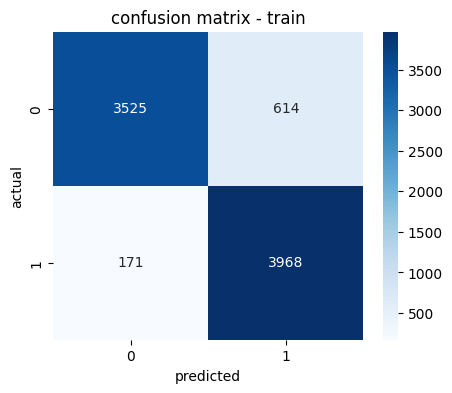


--- test ---
accuracy: 0.7700, recall: 0.7139, precision: 0.5517, f1: 0.6224, auc: 0.8322
classification report:
               precision    recall  f1-score   support

           0     0.8843    0.7903    0.8347      1035
           1     0.5517    0.7139    0.6224       374

    accuracy                         0.7700      1409
   macro avg     0.7180    0.7521    0.7285      1409
weighted avg     0.7960    0.7700    0.7783      1409



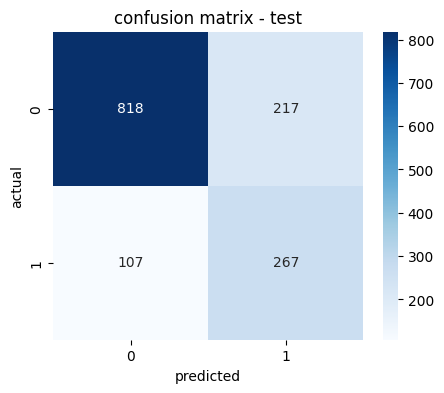

In [16]:
# evaluate
evaluate_xgb_model(xgb_model, X_train_res, y_train_res, X_test, y_test, best_threshold)

In [ ]:
# save model
save_xgb(xgb_model, best_threshold, '/content/drive/MyDrive/XGB_Model/xgb_model_final.pkl', '/content/drive/MyDrive/XGB_Model/best_threshold.pkl')